# Open boundaries (PML) and the radiated impedance

A cavity eigenmode solve normally puts a **closed** wall across each beam-pipe end
(`boundary_conditions='mm'`, a magnetic wall). That is the right model for a *trapped*
mode, whose field has already decayed to nothing by the time it reaches the pipe. It is
the wrong model for a mode **above the beam-pipe cutoff**: such a mode physically
propagates out of the pipe and never comes back, but a closed end reflects it. The solver
then reports it as a sharp resonance with the high ohmic $Q_0$ of the wall material,
instead of the low radiation-limited $Q$ it really has.

Because the reconstructed impedance scales with $Q$,

$$Z(\omega) = \sum_n \frac{\tfrac{1}{2} Q_n (R/Q)_n}{1 + i Q_n\left(\frac{\omega}{\omega_n} - \frac{\omega_n}{\omega}\right)},$$

that error goes straight into $|Z|$.

Setting `boundary_conditions='oo'` replaces both end walls with a **perfectly matched
layer** (PML): an absorbing extension of the beam pipe that lets the wave leave. The
eigenvalues then come out complex, $\omega = \omega_0 + i\,\omega_i$, and the imaginary
part is the radiation loss:

$$Q_{\text{rad}} = \frac{|\omega_0|}{2\,|\omega_i|}.$$

This example solves the same TESLA cavity both ways and checks the result against a
time-domain wakefield run, which has an open pipe by construction.

It also shows the part that is easy to get wrong. An open solve returns **two kinds of
eigenpair above the cutoff** — genuine resonance poles of the open cavity, and modes of
the finite PML *block* — and nothing in the results table separates them. Section 5 is
about telling them apart, because the artifacts turn out to carry the largest $R/Q$ in the
whole set.

See the [eigenmode guide](../../eigenmode) and the [wakefield guide](../../wakefield).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np

from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()
workspace = tempfile.mkdtemp()

## 1. The cavity

A 3-cell TESLA cavity — two end cells around a mid cell — with beam pipes at both ends
(`beampipe='both'`). The pipes matter here: they are what the radiating modes escape
through, and their radius sets the cutoff frequency that divides trapped modes from
propagating ones. Note that it is the **end cell's** aperture that the pipe inherits, not
the mid cell's.

For the lowest monopole (TM$_{01}$) pipe mode that cutoff is

$$f_c = \frac{2.405\,c}{2\pi R_i},$$

with $R_i$ the pipe radius. Everything below $f_c$ is trapped; everything above it
radiates.

beam-pipe radius   39.0 mm
TM01 pipe cutoff   2942.3 MHz


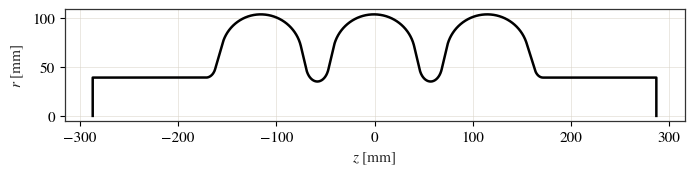

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
#                A       B      a     b    Ri      L         Req     [mm]
midcell   = [  42.00,  42.00, 12.0, 19.0, 35.0, 57.6520, 103.3536]
endcell_l = [  40.34,  40.34, 10.0, 13.5, 39.0, 55.7251, 103.3536]
endcell_r = [  42.00,  42.00,  9.0, 12.8, 39.0, 56.8407, 103.3536]

def tesla(name):
    cav = EllipticalCavity(3, midcell, endcell_l, endcell_r,
                           beampipe='both', name=name)
    cav.set_workspace(os.path.join(workspace, name))
    return cav

cav_closed = tesla('tesla_closed')
cav_open = tesla('tesla_open')

c0 = 299792458.0
Ri = endcell_l[4] * 1e-3                   # pipe radius = end-cell aperture [m]
f_cutoff = 2.405 * c0 / (2 * np.pi * Ri) / 1e6
print(f'beam-pipe radius   {Ri * 1e3:.1f} mm')
print(f'TM01 pipe cutoff   {f_cutoff:.1f} MHz')

cav_closed.plot('geometry')

## 2. The usual solve: closed ends

This is the default. Fifty monopole modes, which covers the first passbands and reaches
well past the cutoff. The wall is copper — the solver's default `conductivity` — so the
ohmic $Q_0$ lands near $3\times10^{4}$. With niobium it would be orders of magnitude
larger, and everything below about $Q_0$ being far too high above cutoff only gets
stronger.

In [3]:
eigen_config = {
    'polarisation': 'monopole',
    'n_modes': 50,          # enough to reach past the pipe cutoff
    'mesh_config': {'h': 10, 'p': 3},
    'force': True,          # skip the overwrite prompt (this notebook is run headless)
}

cav_closed.eigenmode.run(dict(eigen_config, boundary_conditions='mm'))

closed = cav_closed.eigenmode.qois_df
closed[['freq [MHz]', 'Q []', 'R/Q [Ohm]', 'ff [%]']]

,freq [MHz],Q [],R/Q [Ohm],ff [%]
0,1281.681695,29259.855761,2.741072e-02,50.736047
1,1293.828853,29361.598408,4.466535e-03,99.742812
2,1300.008497,29307.536437,3.323323e+02,98.642367
3,2391.165470,31738.384214,1.213930e+00,29.540475
4,2420.570382,31678.231685,1.541171e+01,19.817898
5,2450.896087,31128.031884,8.334843e+01,12.869294
6,2488.067601,54356.346328,8.010684e-11,0.000000
7,2500.606956,53653.119988,1.855275e-12,0.000000
8,2506.659281,53904.788941,9.869645e-11,0.000000
9,2680.499811,44503.121069,5.910755e-02,82.378161


Every mode carries the same $Q$ of order $3\times10^{4}$ — the copper wall loss alone.
Nothing in this table knows that the modes above the cutoff are not confined.

## 3. The same solve with open ends

The only change is `boundary_conditions='oo'`. The solver attaches a PML block to each
pipe mouth, meshes it as part of the same domain, and solves the resulting complex
eigenproblem.

In [4]:
cav_open.eigenmode.run(dict(eigen_config, boundary_conditions='oo'))

opened = cav_open.eigenmode.qois_df
opened[['freq [MHz]', 'Q []', 'Q_wall []', 'Q_rad []', 'Prad [W]', 'R/Q [Ohm]', 'ff [%]']]

,freq [MHz],Q [],Q_wall [],Q_rad [],Prad [W],R/Q [Ohm],ff [%]
0,1281.681798,29260.315870,29260.315880,1.074047e+14,2.085621e-15,2.787675e-02,50.732275
1,1293.829352,29362.851079,29362.851109,3.620846e+13,6.245186e-15,4.543089e-03,99.734303
2,1300.008778,29308.386214,29308.386234,5.481790e+13,4.144788e-15,3.322731e+02,98.629225
3,2391.161958,31740.048907,31740.634775,1.719348e+09,2.430647e-10,1.261099e+00,29.543213
4,2420.562171,31679.864328,31681.635000,5.668023e+08,7.463780e-10,1.557170e+01,19.826512
5,2450.887206,31125.860528,31128.195513,4.149504e+08,1.032288e-09,8.412557e+01,12.861193
6,2488.065946,54319.158317,54319.158317,1.530729e+15,2.840809e-16,9.620969e-30,10.474275
7,2500.607112,53638.559312,53638.559312,4.027846e+16,1.085053e-17,6.103865e-25,48.070677
8,2506.659279,53895.702068,53895.702068,1.811979e+15,2.417801e-16,6.458529e-24,16.354160
9,2680.440575,44419.338366,44493.433181,2.667804e+07,1.755838e-08,1.028658e-01,82.469878


The open run splits the total $Q$ into its two channels,

$$\frac{1}{Q} = \frac{1}{Q_{\text{wall}}} + \frac{1}{Q_{\text{rad}}},$$

and reports each separately. `Q_wall []` is the same ohmic number the closed run gave;
`Q_rad []` is new, and it is what the closed run could not see.

### Two independent measurements of the same loss

`Q_rad []` is obtained by integrating the power actually flowing out of the pipe mouths,

$$P_{\text{rad}} = \oint \tfrac{1}{2}\,\text{Re}\!\left(\mathbf{E}\times\mathbf{H}^{*}\right)\cdot\hat{n}\,dA,
\qquad Q_{\text{rad}} = \frac{\omega U}{P_{\text{rad}}}.$$

`Q_eig []` comes from somewhere else entirely — the imaginary part of the eigenvalue, i.e.
how fast the mode decays. Neither is derived from the other, so comparing them is a real
check. `Q balance []` is that comparison, and equals 1 when they agree:

$$\text{Q balance} = \left(\frac{1}{Q_{\text{diel}}} + \frac{1}{Q_{\text{rad}}}\right) Q_{\text{eig}}.$$

In [5]:
opened[['freq [MHz]', 'R/Q [Ohm]', 'Q_rad []', 'Q_eig []', 'Q balance []']]

,freq [MHz],R/Q [Ohm],Q_rad [],Q_eig [],Q balance []
0,1281.681798,2.787675e-02,1.074047e+14,8.634446e+13,0.803917
1,1293.829352,4.543089e-03,3.620846e+13,2.890070e+13,0.798175
2,1300.008778,3.322731e+02,5.481790e+13,4.353547e+13,0.794183
3,2391.161958,1.261099e+00,1.719348e+09,1.719585e+09,1.000138
4,2420.562171,1.557170e+01,5.668023e+08,5.668300e+08,1.000049
5,2450.887206,8.412557e+01,4.149504e+08,4.149457e+08,0.999989
6,2488.065946,9.620969e-30,1.530729e+15,5.450978e+17,356.103345
7,2500.607112,6.103865e-25,4.027846e+16,8.136113e+18,201.996621
8,2506.659279,6.458529e-24,1.811979e+15,5.881861e+17,324.609664
9,2680.440575,1.028658e-01,2.667804e+07,2.667351e+07,0.999830


Read that table with its `R/Q [Ohm]` column beside it, because the balance splits the modes
in a way that is easy to misread.

Every mode that **couples to the beam at all** sits within about a percent of 1: a surface
integral of $\mathbf{E}\times\mathbf{H}^{*}$ and the decay rate of a complex eigenvalue,
computed without reference to each other, land on the same $Q$. That is the check passing,
and it is the evidence that the layer is genuinely absorbing rather than merely lengthening
the pipe.

Where it fails, it fails on modes with $R/Q \sim 10^{-25}\,\Omega$ — TE modes and other
eigenpairs with no field on the axis — plus the fundamental trio near 1300 MHz. In both
cases the comparison is between two numbers that are essentially zero (radiated fluxes of
order $10^{-13}$ W, or two $Q$ values of order $10^{13}$), so the *ratio* is roundoff.

`Q balance []` is therefore a check on the **absorbing layer**, and a good one. What it is
not is a filter for the impedance: every mode it rejects here contributes $10^{-25}$ kΩ,
and dropping all of them changes $|Z|$ by nothing at all. The modes that really do need
filtering are in section 5 — and every one of them passes this check.

## 4. Which modes actually radiate

Plotting $Q_{\text{rad}}$ against frequency separates the two populations. Below cutoff the
layer receives an evanescent tail and almost no power, so $Q_{\text{rad}}$ runs away to
enormous values — the mode is trapped, exactly as the closed solve assumed. Above cutoff
$Q_{\text{rad}}$ collapses by many orders of magnitude, and *that* is the number that sets
the impedance.

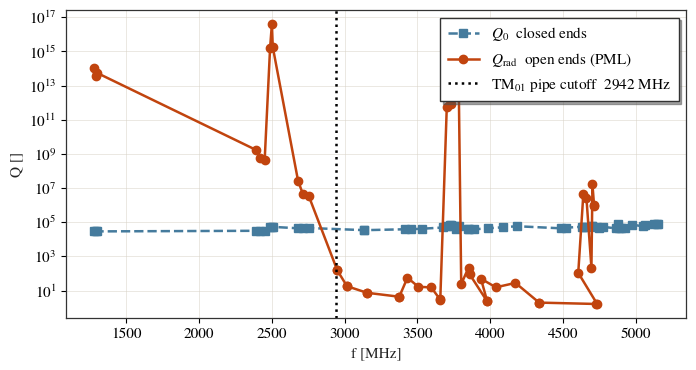

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(closed['freq [MHz]'], closed['Q []'], 's--', label=r'$Q_0$  closed ends')
ax.semilogy(opened['freq [MHz]'], opened['Q_rad []'], 'o-',
            label=r'$Q_\mathrm{rad}$  open ends (PML)')
ax.axvline(f_cutoff, ls=':', color='k',
           label=f'TM$_{{01}}$ pipe cutoff  {f_cutoff:.0f} MHz')
ax.set_xlabel('f [MHz]')
ax.set_ylabel('Q []')
ax.legend()
plt.show()

## 5. Not every eigenvalue above the cutoff is a mode

Here is the part that costs people a factor of five.

A PML is an *approximation* to an open pipe. The physical resonance poles of the open
cavity are fixed by its geometry, so they do not care how long the absorbing block is. The
finite block, however, is itself a resonator, and it contributes eigenpairs of its own.
Those PML-block modes are damped — the layer absorbs them — so they arrive with a
perfectly plausible low $Q$, a `Q balance []` of 1.00, and no other tell.

The one thing that distinguishes them is that they are **properties of the layer, not of
the cavity**. So change the layer. `pml_length` sets the block length in metres (the
default is 3× the pipe radius) and `pml_alpha` its complex stretch.

In [7]:
cav_long = tesla('tesla_long_pml')
cav_long.eigenmode.run(dict(eigen_config, boundary_conditions='oo',
                            pml_length=0.234))          # default here is 0.117 m

longer = cav_long.eigenmode.qois_df
print(f'default PML : {len(opened):2d} modes')
print(f'2x PML      : {len(longer):2d} modes')

default PML : 50 modes
2x PML      : 50 modes


`cav.eigenmode.stable_modes()` keeps the modes the second solve also found, at the same
frequency and $Q$:

In [8]:
trusted = cav_open.eigenmode.stable_modes(cav_long.eigenmode)

# Judge only where BOTH runs have modes. Each run returns its lowest n_modes, so the
# two need not reach the same ceiling, and a mode above the other run's highest has no
# partner to be matched against -- it would look 'unstable' for that reason alone.
f_top = min(opened['freq [MHz]'].max(), longer['freq [MHz]'].max())
print(f"default PML reaches {opened['freq [MHz]'].max():.0f} MHz, "
      f"2x PML reaches {longer['freq [MHz]'].max():.0f} MHz")
print(f'comparing below {f_top:.0f} MHz, where both runs have modes')

judged = ((opened['freq [MHz]'] > f_cutoff) & (opened['R/Q [Ohm]'] > 1e-3)
          & (opened['freq [MHz]'] <= f_top))
kept = judged & opened.index.isin(trusted.index)
print()
print(f'beam-coupled modes above cutoff : {judged.sum()}')
print(f'   ... that survive a longer PML: {kept.sum()}')

dropped = opened[judged & ~opened.index.isin(trusted.index)]
dropped[['freq [MHz]', 'Q []', 'R/Q [Ohm]', 'Q balance []']]

default PML reaches 4735 MHz, 2x PML reaches 4246 MHz
comparing below 4246 MHz, where both runs have modes

beam-coupled modes above cutoff : 21
   ... that survive a longer PML: 8


,freq [MHz],Q [],R/Q [Ohm],Q balance []
12,2950.214180,151.396836,36.941644,1.000044
13,2950.223599,150.919190,59.271214,1.000064
14,3016.583234,18.212891,27.014756,1.000088
15,3016.650833,18.169833,42.975550,1.000091
16,3154.107441,7.478490,78.352968,1.000284
17,3154.569648,7.493899,29.459910,1.000414
18,3372.659884,4.429038,127.809096,1.000591
19,3375.632520,4.417115,18.362997,1.000956
23,3655.885216,3.047149,148.803719,1.001164
24,3657.359710,3.022662,11.479758,1.001945


That is the whole problem in one table. The discarded modes

- have the **lowest $Q$** of any mode in the set, so they are the **broadest** — each one
  spans hundreds of MHz and contributes across the entire above-cutoff range;
- carry the **largest $R/Q$** of any mode in the set, over $100\,\Omega$ where the genuine
  poles sit in the tens;
- and have `Q balance []` of 1.00, so the layer check waves every one of them through.

They dominate the reconstructed impedance, and they are artifacts of the box.

Note also what does *not* work as a test: refining the mesh. The mesh does not change the
PML block's dimensions, so a block mode survives an `h` refinement happily. It is
`pml_length` or `pml_alpha` that has to move.

## 6. What that does to the impedance

`cav.eigenmode.impedance()` sums the modes as parallel RLC resonators, using each mode's
own `Q []`.

Asking the **closed** solve for an impedance is refused outright — its above-cutoff $Q$
values are not physical, so there is no useful spectrum to build from them:

In [9]:
cav_closed.eigenmode.impedance('longitudinal')

ERROR:: refusing to reconstruct impedance from a CLOSED-boundary eigenmode solve. The pipe ends reflect, so every mode above the beam-pipe cutoff keeps its ohmic Q0 instead of its radiation Q and |Z| comes out ~100-1000x too high. Re-run with boundary_conditions='oo' (an open/PML end -- see the open_boundary_impedance example), use cav.wakefield for the broadband answer, or pass an explicit Q= if you know the loaded Q and want the reconstruction anyway.


""


To see *how far off* it would have been, we can force the issue: `Q=` states the quality
factors explicitly, which bypasses the check. Handing it back the closed solve's own
`Q []` reproduces the reconstruction that used to happen silently.

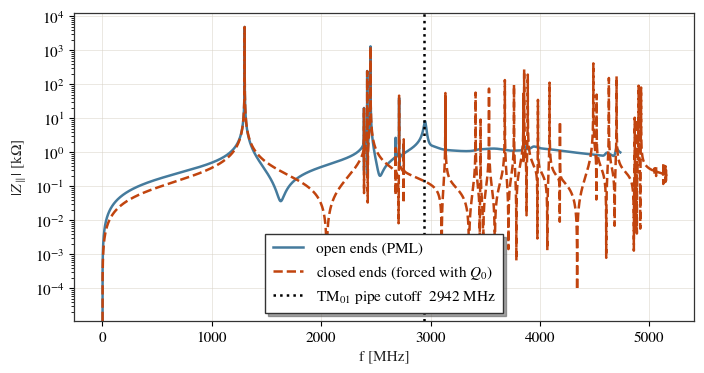

In [10]:
Q_closed = closed.sort_values('freq [MHz]')['Q []'].to_numpy()

ax = cav_open.eigenmode.plot_impedance('longitudinal', show=False,
                                       label='open ends (PML)')
cav_closed.eigenmode.plot_impedance('longitudinal', ax=ax, show=False, Q=Q_closed,
                                    ls='--', label='closed ends (forced with $Q_0$)')
ax.axvline(f_cutoff, ls=':', color='k',
           label=f'TM$_{{01}}$ pipe cutoff  {f_cutoff:.0f} MHz')
ax.legend()
plt.show()

Below the cutoff line the two curves lie on top of each other: the PML does not disturb a
trapped mode. Above it they separate by orders of magnitude, and the open-boundary curve
replaces the spurious needles with the broad humps a propagating mode really produces.

## 7. Checking against the wakefield

A time-domain wakefield run drives the cavity with a bunch through an open pipe, so it
includes radiation without being asked to. It is the independent check on everything above
— with two caveats that decide what the comparison can actually show.

**The bunch sets how far up the comparison means anything.** The impedance is the wake
spectrum deconvolved by the bunch spectrum, and a Gaussian bunch of length $\sigma_z$ has
little left to deconvolve above roughly $c/(2\pi\sigma_z)$ — 2.7 GHz at the 25 mm used
here. Above that the wakefield curve is increasingly noise-dominated, so read the shapes
rather than the values. A shorter bunch moves that limit up (5 mm reaches past 13 GHz) at
the cost of a much longer run.

**Narrow resonances will not match, and should not.** A 50 m wake is a 167 ns window, so the
narrowest resonance it can resolve has $Q \approx f T \sim 10^{2}$–$10^{3}$. The
fundamental's real $Q$ is $2.9\times10^{4}$, so the wakefield peak at 1300 MHz is
truncation-limited and lands orders of magnitude below the eigenmode value. That is a
property of the reference, not an error in the modes. **Below cutoff, compare $f$ and
$R/Q$; above it, compare $|Z|$.**

In [11]:
cav_open.wakefield.run({'MROT': 0, 'wakelength': 50, 'bunch_length': 25,
                        'force': True})
cav_open.wakefield.qois

{'|k_loss| [V/pC]': 0.51,
 'k_FM [V/pC]': 0.44402,
 'k_loss_HOM [V/pC]': 0.06597999999999998}

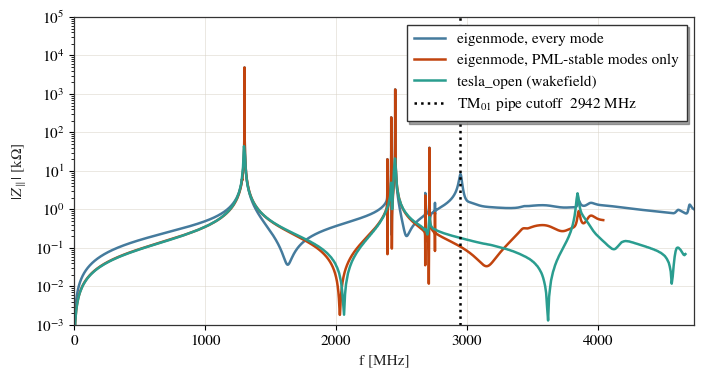

In [12]:
f_max = opened['freq [MHz]'].max()

ax = cav_open.eigenmode.plot_impedance('longitudinal', show=False,
                                       label='eigenmode, every mode')
# the same call, restricted to the PML-stable modes
cav_open.eigenmode.plot_impedance('longitudinal', ax=ax, show=False, modes=trusted,
                                  label='eigenmode, PML-stable modes only')
cav_open.wakefield.plot_impedance('longitudinal', ax=ax, show=False)

ax.axvline(f_cutoff, ls=':', color='k',
           label=f'TM$_{{01}}$ pipe cutoff  {f_cutoff:.0f} MHz')
ax.set_xlim(0, f_max)          # the eigenmode sum stops at the highest computed mode
ax.set_ylim(1e-3, 1e5)
ax.legend()
plt.show()

Above the cutoff the filtered curve drops towards the wakefield while the unfiltered one
stays well above it — the collective contribution of those few broad artifacts. Section 8
puts a number on that excess, on a quantity that can actually carry one. Below
the cutoff nothing changes — the filter removes nothing there — and the eigenmode peaks
tower over the wakefield exactly as the truncation argument predicts.

What remains above the cutoff is the RLC model itself. A sum of parallel resonators gives
every mode a positive-real shunt impedance, so modes whose linewidths overlap add **in
phase**; that is exact for an isolated resonance and progressively wrong as modes broaden.
Representing it properly needs complex mode residues, and the solver does report them
(`Re(R/Q) [Ohm]` / `Im(R/Q) [Ohm]`, whenever the eigenvalue is complex). Their magnitudes
are exact, but their phases are not yet physical — `impedance(model='qnm')` exists, warns,
and is a diagnostic rather than an answer. Filtering the mode set, above, is what works
today.

## 8. The comparison that actually settles it: the loss factor

Peak $|Z|$ is a bad thing to compare. A 50 m wake is a 167 ns window, so the narrowest
line the wakefield can resolve has $Q \sim 10^2$–$10^3$ against the fundamental's
$2.9\times10^4$: its peak is truncation-limited and lands orders of magnitude low. That
says nothing about whether the modes are right.

The **loss factor** does not have that problem. $k$ is an *integral* of $\mathrm{Re}\,Z$
over the bunch spectrum, and truncating a wake broadens a resonance while preserving its
area. So $k$ compares cleanly even when $|Z|$ cannot.

Each mode contributes a point-charge loss factor

$$k_n = \frac{V_n^2}{4U_n} = \frac{\omega_n}{4}\left(\frac{R}{Q}\right)_n,$$

and a bunch of rms length $\sigma_z$ weights it by the form factor
$\exp[-(\omega_n\sigma_z/c)^2]$. That weighting is the whole difference between a point
charge and a real bunch — it is **not** a limitation of the eigenmode method, and once it
is applied the two calculations are directly comparable.

ABCI exports its own cumulative $k(<f)$, so the two can simply be overlaid.

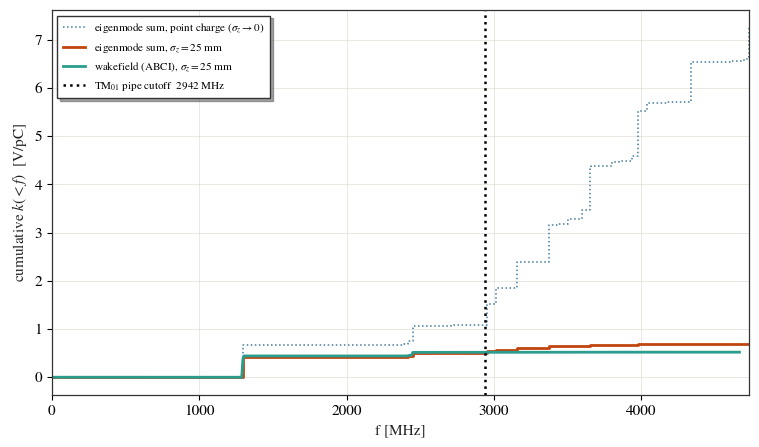

In [13]:
C0 = 299792458.0
sigma_z = 25e-3                      # the bunch the wakefield ran with [m]

m = opened.sort_values('freq [MHz]')
fe = m['freq [MHz]'].to_numpy()
k_point = 2 * np.pi * fe * 1e6 * m['R/Q [Ohm]'].to_numpy() / 4 * 1e-12   # V/pC
k_bunch = k_point * np.exp(-(2 * np.pi * fe * 1e6 * sigma_z / C0) ** 2)

wk = cav_open.wakefield.wake_z[['fk [MHz]', 'k_loss(f) [V/pC]']].dropna()
fw = wk['fk [MHz]'].to_numpy()
kw = wk['k_loss(f) [V/pC]'].to_numpy()


def staircase(f, k, f_end):
    """A mode sum is a step function: flat between modes, jumping at each one."""
    xs, ys, run = [0.0], [0.0], 0.0
    for fi, ki in zip(f, k):
        run += ki
        xs += [fi, fi]
        ys += [ys[-1], run]
    return np.array(xs + [f_end]), np.array(ys + [ys[-1]])


f_end = fe.max()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(*staircase(fe, k_point, f_end), lw=1.1, ls=':',
        label=r'eigenmode sum, point charge ($\sigma_z \to 0$)')
ax.plot(*staircase(fe, k_bunch, f_end), lw=2.0,
        label=r'eigenmode sum, $\sigma_z = 25$ mm')
ax.plot(fw, kw, lw=2.0, label=r'wakefield (ABCI), $\sigma_z = 25$ mm')
ax.axvline(f_cutoff, ls=':', color='k',
           label=f'TM$_{{01}}$ pipe cutoff  {f_cutoff:.0f} MHz')
ax.set_xlabel('f [MHz]')
ax.set_ylabel(r'cumulative $k(<f)$  [V/pC]')
ax.set_xlim(0, f_end)
ax.legend(fontsize=8, loc='upper left')
plt.show()

In [14]:
below = fe <= f_cutoff
print(f'{'':32}{'eigenmode':>12}{'ABCI':>12}')
print(f'{'k, modes below cutoff':32}{k_bunch[below].sum():12.4f}'
      f'{np.interp(f_cutoff, fw, kw):12.4f}')
print(f'{'k, all computed modes':32}{k_bunch.sum():12.4f}{kw[-1]:12.4f}')
print(f'{'  (above-cutoff modes add)':32}{k_bunch[~below].sum():12.4f}'
      f'{kw[-1] - np.interp(f_cutoff, fw, kw):12.4f}')
print()
print('ABCI time-domain loss factors:', cav_open.wakefield.qois)

                                   eigenmode        ABCI
k, modes below cutoff                 0.5029      0.5170
k, all computed modes                 0.6966      0.5197
  (above-cutoff modes add)            0.1937      0.0027

ABCI time-domain loss factors: {'|k_loss| [V/pC]': 0.51, 'k_FM [V/pC]': 0.44402, 'k_loss_HOM [V/pC]': 0.06597999999999998}


Below the cutoff the two curves lie on top of each other — the same steps at the same
frequencies, agreeing to about 3% all the way up. That is the eigenmode reconstruction
working exactly as advertised, and it is a far stronger statement than the $|Z|$ overlay
could make.

At the cutoff they part company. The wakefield goes essentially flat; the mode sum keeps
climbing, and the modes it climbs on are the broad, low-$Q$, large-$R/Q$ ones from section
5 — the PML-block artifacts.

The dotted curve is there to head off a natural misreading: the point-charge sum is about
fourteen times the 25 mm one. If the eigenmode side really were "stuck at zero bunch
length" it would sit far above the wakefield everywhere, not agree with it to 3%. It does
not, because the form factor has been applied.

### Why $R/Q$ stops being a property of the geometry

$R/Q = V^2/(\omega U)$ is purely geometric — no material, no wall loss — *for a confined
mode*. Every trapped mode in this run reports the identical $U$, because the eigenvector is
normalised and the whole field is inside the cavity.

A radiating mode is not confined, and $U$ is only the energy inside the **computational
domain**. Above the cutoff the modes here keep between 16% and 99% of their normalised
energy inside the physical region, the rest having leaked into the absorbing layer. So
$U$ — and with it $R/Q$ and $k_n = V^2/4U$ — measures where you chose to truncate, not the
cavity. The modes with the most energy outside come back with the most inflated $R/Q$, and
those are precisely the ones inflating the loss factor above the cutoff.

That is the concrete form of the general statement: above the pipe cutoff there is no
discrete mode to attach a geometric $R/Q$ to.

## What to take away

- Reconstructing an impedance from a closed-boundary solve is refused: above the beam-pipe
  cutoff the reflection at the end wall replaces a radiation $Q$ with the ohmic $Q$ of the
  wall. Pass `Q=` only if you know the loaded $Q$ yourself.
- `boundary_conditions='oo'` fixes that at the source, at the cost of one extra PML block
  per pipe end in the mesh.
- **Above the cutoff, solve twice.** A single open solve mixes real resonance poles with
  modes of the finite absorbing block, and the artifacts are the broad, high-$R/Q$ ones
  that dominate a reconstructed impedance. Vary `pml_length` (or `pml_alpha` — *not* the
  mesh) and keep what does not move, with `cav.eigenmode.stable_modes()`.
- `Q balance []` validates the absorbing layer. It does not identify these artifacts, which
  pass it at 1.00.
- Below the cutoff the wakefield is the one that cannot resolve a narrow line; compare $f$
  and $R/Q$ there, not peak $|Z|$. And keep the bunch short enough that the wake spectrum
  still carries information at the frequencies being compared.
- Compare **loss factors**, not peak $|Z|$. $k$ is an integral over the bunch spectrum
  and survives the wake truncation that makes a high-$Q$ peak incomparable. Weighted by
  the same bunch, the mode sum reproduces the wakefield to ~3% below the cutoff.
- $R/Q$ is geometry-only for a **confined** mode. Above the cutoff part of the field lives
  outside the computational domain, so $U$ — and therefore $R/Q$ — depends on where the
  domain ends.
- The wakefield solver remains the reference for broadband impedance: an eigenmode
  reconstruction contains exactly the modes that were solved and nothing else — no
  broadband or resistive-wall contribution, and nothing above the highest computed mode.

## Where to go next

- [The TESLA elliptical cavity](elliptical_tesla.ipynb) — fundamental mode figures of merit and passbands.
- [Wakefield and impedance (ABCI)](../wakefield/impedance.ipynb) — wake potential details and bunch length parameters.